___

> # **1. Motivation.**



<span style="color:red">

* What is your dataset?

* Why did you choose this/these particular dataset(s)?

* What was your goal for the end user's experience?
</span>.

***

> # **2. Basic stats.**

<span style="color:red">

* Write about your choices in data cleaning and preprocessing

* Write a short section that discusses the dataset stats, containing key points/plots from your exploratory data analysis.
</span>.

> ### **2.1.  Dataimport and preprocessing**

In [ ]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

import geopandas as gpd
import matplotlib.pyplot as plt

import folium
from folium.plugins import HeatMap
import re



> **2.1.1 Reading data files**

In [20]:
# Loading shp files
traffic_noise = gpd.read_file("vejstoej_boliger_2022_udv/vejstoej_boliger_2022_udv.shp")
playground= gpd.read_file("legeplads/legeplads.shp")
day_care = gpd.read_file("daginstitutioner/daginstitutionerMPoint.shp")
green_areas= gpd.read_file("park_groent_omr_oversigtskort/park_groent_omr_oversigtskort.shp") 

# Air quality files
df_list_HC = pd.read_html("Aktuel luftkvalitet i Danmark.html")
df_list_jagtvej = pd.read_html("Aktuel luftkvalitet i Danmark jagtvej.html")
df_list_oersted = pd.read_html("Aktuel luftkvalitet i Danmark HCoersted.html")

# Load data from url
environmental_zones = gpd.read_file("https://wfs-kbhkort.kk.dk/k101/ows?service=WFS&version=1.0.0&request=GetFeature&typeName=k101:miljozone&outputFormat=json&SRSNAME=EPSG:4326")

> **2.1.2 Cleaning files**

<span style="color:blue">

**NOTER**

* Tilføj machine learning udfyldning af dataen

</span>

In [21]:
def datetime(df_list):
    df= df_list[0]
    df["Målt (starttid)"] = pd.to_datetime(df["Målt (starttid)"], format="%d-%m-%Y %H:%M")
    df = df.sort_values("Målt (starttid)")
    df.set_index("Målt (starttid)", inplace=True)
    return df

df_HC = datetime(df_list_HC)
df_jagtvej = datetime(df_list_jagtvej)
df_oersted = datetime(df_list_oersted)


> ## **2.2 Data set stats and summary**

<span style="color:blue">

**NOTER**

* Flere små summaru statistics over alle dataset

</span>

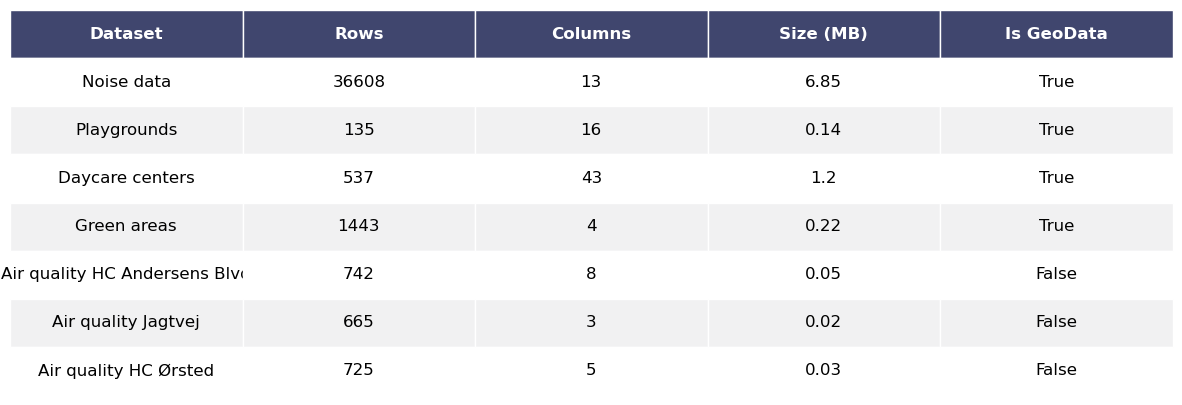

In [ ]:
def dataset_summary(name, df):
    mem = df.memory_usage(deep=True).sum() / 1024**2 # Convert bytes to MB
    return {
        "Navn": name,
        "Antal rækker": len(df),
        "Antal kolonner": df.shape[1],
        "Størrelse (MB)": round(mem, 2),
        "Geo-data": isinstance(df, gpd.GeoDataFrame)
    }

data = [
    dataset_summary("Støjdata", traffic_noise),
    dataset_summary("Legepladser", playground),
    dataset_summary("Daginstitutioner", day_care),
    dataset_summary("Grønne områder", green_areas),
    dataset_summary("Luftkvalitet HC", df_list_HC[0]),
    dataset_summary("Luftkvalitet Jagtvej", df_list_jagtvej[0]),
    dataset_summary("Luftkvalitet Ørsted", df_list_oersted[0]),
]

summary_df = pd.DataFrame(data)
summary_df_english = summary_df.rename(columns={
    "Navn": "Dataset",
    "Antal rækker": "Rows",
    "Antal kolonner": "Columns",
    "Størrelse (MB)": "Size (MB)",
    "Geo-data": "Is GeoData"
})
summary_df_english['Dataset'] = summary_df_english['Dataset'].replace({
    "Støjdata": "Noise data",
    "Legepladser": "Playgrounds",
    "Daginstitutioner": "Daycare centers",
    "Grønne områder": "Green areas",
    "Luftkvalitet HC": "Air quality HC Andersens Blvd",
    "Luftkvalitet Jagtvej": "Air quality Jagtvej",
    "Luftkvalitet Ørsted": "Air quality HC Ørsted"
})
def render_mpl_table(data, col_width=3.0, row_height=0.625, font_size=12,
                     header_color='#40466e', row_colors=['#f1f1f2', 'w'],
                     edge_color='w', bbox=[0, 0, 1, 1], header_columns=0,
                     ax=None, **kwargs):
    if ax is None:
        size = (np.array(data.shape[::-1]) + np.array([0, 1])) * np.array([col_width, row_height])
        fig, ax = plt.subplots(figsize=size)
        ax.axis('off')

    mpl_table = ax.table(cellText=data.values, bbox=bbox, colLabels=data.columns, cellLoc='center', **kwargs)

    mpl_table.auto_set_font_size(False)
    mpl_table.set_fontsize(font_size)

    for k, cell in mpl_table._cells.items():
        cell.set_edgecolor(edge_color)
        if k[0] == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor(header_color)
        else:
            cell.set_facecolor(row_colors[k[0] % len(row_colors)])
    return ax

ax = render_mpl_table(summary_df_english, header_columns=0, col_width=3.0)
plt.savefig("summary_table.png", bbox_inches='tight', dpi=300)
plt.show()


Noise data is quite larger than the other dataset. 
The data is aggregated for a lot of the data. 
Describe which files they are

In [38]:

df_HC.describe()


,CO,NO2,NOX,SO2,O3,PM10,PM2.5
count,742.000000,699.000000,684.000000,640.000000,742.000000,740.000000,732.000000
mean,25.509434,169.247496,312.179825,38.390625,571.532345,272.781081,184.266393
std,9.115501,125.038746,277.855111,27.088227,174.592901,162.199457,127.479217
min,8.000000,3.000000,5.000000,2.000000,38.000000,14.000000,12.000000
25%,19.000000,73.500000,117.500000,14.000000,473.000000,152.500000,88.000000
50%,24.000000,139.000000,246.000000,32.000000,598.000000,241.500000,138.000000
75%,30.000000,238.500000,423.500000,59.000000,708.000000,361.500000,254.500000
max,63.000000,706.000000,2364.000000,99.000000,919.000000,1004.000000,607.000000


___
> # **3. Data Analysis**

<span style="color:red">

* Describe your data analysis and explain what you've learned about the dataset.

* If relevant, talk about your machine-learning.

</span>.


<span style="color:blue">

**NOTER**

* Polar bar chart over hvornår der er luftforurening
* Gør så man kan scrolle igennem tidsserie dataen
* Man kunne godt lige kigge på sammenghængen mellem den her luftforurening og bilkørsel

</span>

In [ ]:
def plot_luftforurening(df):
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame index must be a DatetimeIndex")

    unique_days = df.index.normalize().unique()
    tickvals = unique_days
    ticktext = [d.strftime("%d-%b") for d in unique_days]
    numeric_cols = df.select_dtypes(include='number').columns

    fig = go.Figure()

    for col in numeric_cols:
        fig.add_trace(go.Scatter(
            x=df.index,
            y=df[col],
            mode='lines',
            name=col
        ))

    fig.update_layout(
        title="Tidsserie af luftforurening på H. C. Andersens Boulevard",
        xaxis_title="Dato",
        yaxis_title="Koncentration (μg/m³ eller tilsvarende)",
        xaxis=dict(
            tickvals=tickvals,
            ticktext=ticktext,
            tickangle=45,
            showgrid=True
        ),
        yaxis=dict(showgrid=True),
        legend=dict(title="Stof"),
        template="plotly_white",
        height=600,
        width=1000
    )

    fig.show()
    
plot_luftforurening(df_HC)
plot_luftforurening(df_jagtvej)
plot_luftforurening(df_oersted)

In [ ]:
#make a polar bar chart of the air quality data pr day so 1 bar for each hour
def plot_polar_bar(df):
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame index must be a DatetimeIndex")

    df = df.resample('H').mean()
    df['Hour'] = df.index.hour

    if 'NOX' not in df.columns:
        raise ValueError("The DataFrame does not contain a 'NOX' column")

    fig = go.Figure()

    fig.add_trace(go.Barpolar(
        r=df['NOX'],
        theta=df['Hour'],
        name='NOX',
        hovertemplate='%{r:.2f} μg/m³<br>Time: %{theta}h',
        marker=dict(line=dict(color='black', width=1))
    ))

    fig.update_layout(
        title="Luftforurening pr time (NOX)",
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, df['NOX'].max() + 10]
            ),
            angularaxis=dict(
                tickmode='array',
                tickvals=list(range(0, 24)),
                ticktext=[f"{i}:00" for i in range(24)]
            )
        ),
        showlegend=True,
        height=800,
        width=800
    )

    fig.show()
plot_polar_bar(df_HC)

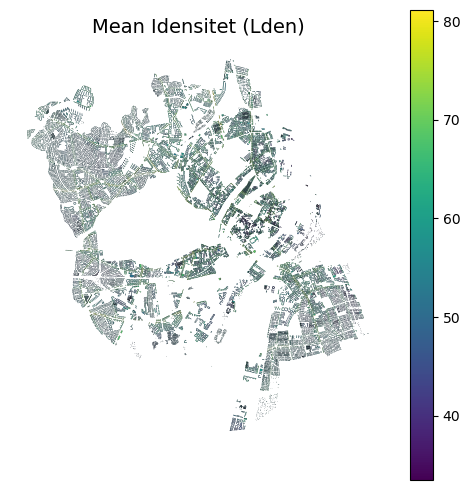

In [34]:
def traffic_noise_plot(df):
    fig, ax = plt.subplots(figsize=(5, 5))  # Decreased the figure size
    df.plot(column='mean_lden',
         cmap='viridis', 
         linewidth=0.1,
         edgecolor='black',
         legend=True,
         ax=ax)

    ax.set_title("Mean Idensitet (Lden)", fontsize=14)  # Adjusted font size
    ax.axis('off')
    plt.tight_layout()
    plt.show()

traffic_noise_plot(traffic_noise)

In [ ]:

def plot_playgrounds(df):
    # Extract the first point from each geometry (assuming it's a MULTIPOINT with one coordinate)
    df['lon'] = df.geometry.apply(lambda geom: geom.geoms[0].x)
    df['lat'] = df.geometry.apply(lambda geom: geom.geoms[0].y)

    fig = px.scatter_mapbox(
    df,
    lat='lat',
    lon='lon',
    hover_name='navn',  # Playground name
    hover_data=['adressebes', 'aldersgrup', 'graffitir0'],
    zoom=11,
    height=700
)
    fig.update_traces(marker=dict(size=12)) 
    fig.update_layout(mapbox_style='open-street-map')
    fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0}, title="Playgrounds in Copenhagen")

    fig.show()
    fig.write_image("playgrounds_map.png", scale=2)

plot_playgrounds(playground)



In [ ]:

def plot_day_care(df):
    bydel_counts = df['bydel'].value_counts().reset_index() #Counting the number of institutions per district
    bydel_counts.columns = ['City district', 'Number of institutions']

    fig = px.bar(bydel_counts,
             x='City district',
             y='Number of institutions',
             title='Number of institutions per city district in Copenhagen',
             labels={'City district': 'City district', 'Number of institutions': 'Number'},
             text='Number of institutions',
             height=700)

    fig.update_traces(textposition='outside')
    fig.update_layout(xaxis_tickangle=-45)
    fig.show()

    fig.write_image("daginst.png", scale=2) # Save the figure as a PNG file

plot_day_care(day_care)


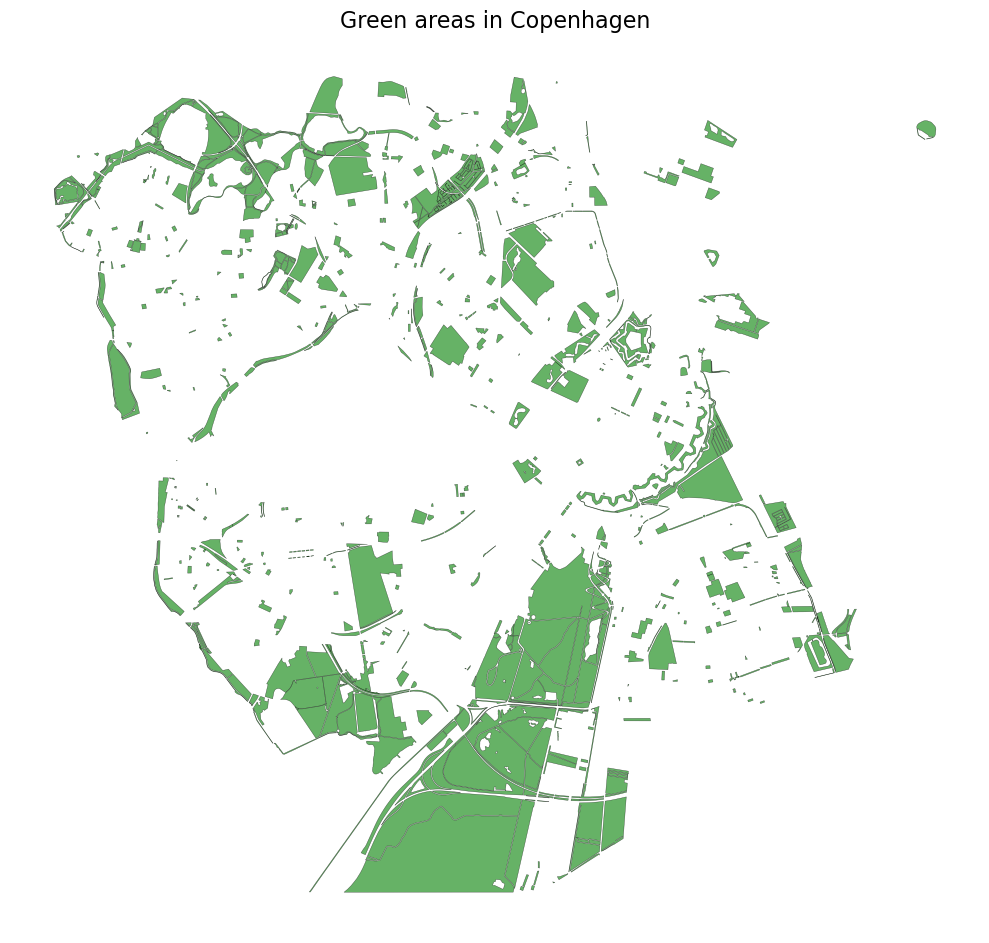

In [32]:


def plot_copenhagen_green_areas(df):
    grøn_kbh = df[df['kommune'] == 'København'] # Filter for Copenhagen municipality
    fig, ax = plt.subplots(figsize=(10, 12))
    grøn_kbh.plot(ax=ax, color='green', edgecolor='black', linewidth=0.3, alpha=0.6)
    ax.set_title('Green areas in Copenhagen', fontsize=16)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig('green_areas.png')
    plt.show()

plot_copenhagen_green_areas(green_areas)



In [ ]:
def plot_environmentalZones(data):
    center = [55.6761, 12.5683]  # Latitude, Longitude of Copenhagen
    m = folium.Map(location=center, zoom_start=12)     # Create a folium map centered at Copenhagen
    folium.GeoJson(data, name="Miljozone").add_to(m)  # Add the environmental zone (miljozone) to the ma
    return m  # Return the map object to display it in the notebook

plot_environmentalZones(environmental_zones)

---

> # **4. Genre**




<span style="color:red">

* Which genre of data story did you use?

* Which tools did you use from each of the 3 categories of Visual Narrative (Figure 7 in Segal and Heer). Why?

* Which tools did you use from each of the 3 categories of Narrative Structure (Figure 7 in Segal and Heer). Why?

</span>.

___
> # **5. Visualizations**


<span style="color:red">

* Explain the visualizations you've chosen.

* Why are they right for the story you want to tell?

</span>.

___
> # **6. Discussion.**

<span style="color:red">

* Think critically about your creation

* What went well?,

* What is still missing? What could be improved?, Why?

</span>.

___
> # **7. Contributions.**

<span style="color:red">

* You should write (just briefly) which group member was the main responsible for which elements of the assignment. (I want you guys to understand every part of the assignment, but usually there is someone 

* who took lead role on certain portions of the work. That's what you should explain).

* It is not OK simply to write "All group members contributed equally".


</span>.



___
> # **8. Make sure that you use references when they're needed and follow academic standards.**